### Group Prject - London Bike Rentals

In this project, you will work with the London Bikes dataset, which records daily bike rentals in the city along with key variables such as dates, weather conditions, and seasonality.

The goal is to apply the full data analytics workflow:

- Clean and prepare the dataset.

- Explore the data through visualisation.

- Construct and interpret confidence intervals.

- Build a regression model to explain variation in bike rentals.

- By the end, you will connect statistical concepts with practical Python analysis.

In [9]:
## Import libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

bikes = pd.read_csv("../Data/london_bikes.csv")
bikes.head()
bikes["date"] = pd.to_datetime(bikes["date"])

# Create useful date variables
bikes["year"] = bikes["date"].dt.year
bikes["month"] = bikes["date"].dt.month
bikes["month_name"] = bikes["date"].dt.month_name()
bikes["day"] = bikes["date"].dt.day
bikes["day_of_week"] = bikes["date"].dt.day_name()

# Create season
bikes["season"] = np.select(
    [
        bikes["month"].isin([12, 1, 2]),
        bikes["month"].isin([3, 4, 5]),
        bikes["month"].isin([6, 7, 8]),
        bikes["month"].isin([9, 10, 11])
    ],
    ["Winter", "Spring", "Summer", "Autumn"],
    default="Unknown"
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
bikes["season"] = pd.Categorical(
    bikes["season"],
    categories=season_order,
    ordered=True
)

bikes.head()



,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,...,snow_depth,sunshine,mean_temp,min_temp,max_temp,weekend,month_name,day,day_of_week,season
0,2010-07-30 00:00:00+00:00,6897,2010,Fri,7,30,6.0,65.0,10147.0,157.0,...,NaN,31.0,17.7,12.3,25.1,False,July,30,Friday,Summer
1,2010-07-31 00:00:00+00:00,5564,2010,Sat,7,30,5.0,70.0,10116.0,184.0,...,NaN,47.0,21.1,17.0,23.9,True,July,31,Saturday,Summer
2,2010-08-01 00:00:00+00:00,4303,2010,Sun,8,30,7.0,63.0,10132.0,89.0,...,NaN,3.0,19.3,14.6,23.4,True,August,1,Sunday,Summer
3,2010-08-02 00:00:00+00:00,6642,2010,Mon,8,31,7.0,59.0,10168.0,134.0,...,NaN,20.0,19.5,15.6,23.6,False,August,2,Monday,Summer
4,2010-08-03 00:00:00+00:00,7966,2010,Tue,8,31,5.0,66.0,10157.0,169.0,...,NaN,39.0,17.9,12.1,20.1,False,August,3,Tuesday,Summer


**1. Data Cleaning**

Check for missing values across columns. How would you handle them?

Inspect the date column and ensure it is correctly formatted as datetime. Extract useful features (year, month, day, day of week, season).

Convert categorical variables (e.g., season, weather) to appropriate categories in Python.

Ensure numeric columns (e.g., bikes rented, temperature) are in the right format.

In [10]:
#check for missing values and proportions 
bikes.isna().sum()
bikes.isna().mean() * 100


date             0.000000
bikes_hired      0.000000
year             0.000000
wday             0.000000
month            0.000000
week             0.000000
cloud_cover      0.668829
humidity         1.682205
pressure         0.628293
radiation        0.810701
precipitation    0.628293
snow_depth       6.120794
sunshine         0.628293
mean_temp        0.628293
min_temp         1.256587
max_temp         0.628293
weekend          0.000000
month_name       0.000000
day              0.000000
day_of_week      0.000000
season           0.000000
dtype: float64

Missing values are low for most of the rows, but snow_depth has around 6% of missing values and min temp and himidity also 1.25 and 1.68. 
Two opgions: delete rows or fill them with median
wfilling with median seems like a better idea because otherwise we could lose important rows of data

In [11]:
#check data type 
bikes.dtypes

date             datetime64[us, UTC]
bikes_hired                    int64
year                           int32
wday                             str
month                          int32
week                           int64
cloud_cover                  float64
humidity                     float64
pressure                     float64
radiation                    float64
precipitation                float64
snow_depth                   float64
sunshine                     float64
mean_temp                    float64
min_temp                     float64
max_temp                     float64
weekend                         bool
month_name                       str
day                            int32
day_of_week                      str
season                      category
dtype: object

In [12]:
bikes["humidity"] = bikes["humidity"].fillna(bikes["humidity"].median())
bikes["snow_depth"] = bikes["snow_depth"].fillna(bikes["snow_depth"].median())
bikes["min_temp"] = bikes["min_temp"].fillna(bikes["min_temp"].median())

#we can do the same for every column or we can use the code to fill all numeric columns with median values
numeric_cols = bikes.select_dtypes(include="number").columns
bikes[numeric_cols] = bikes[numeric_cols].fillna(bikes[numeric_cols].median())

bikes.isna().mean()*100

date             0.0
bikes_hired      0.0
year             0.0
wday             0.0
month            0.0
week             0.0
cloud_cover      0.0
humidity         0.0
pressure         0.0
radiation        0.0
precipitation    0.0
snow_depth       0.0
sunshine         0.0
mean_temp        0.0
min_temp         0.0
max_temp         0.0
weekend          0.0
month_name       0.0
day              0.0
day_of_week      0.0
season           0.0
dtype: float64

In [13]:
#convert all the columns to the correct data type 
bikes["day_of_week"] = bikes["day_of_week"].astype("category")
bikes["month_name"] = bikes["month_name"].astype("category")

bikes.dtypes

date             datetime64[us, UTC]
bikes_hired                    int64
year                           int32
wday                             str
month                          int32
week                           int64
cloud_cover                  float64
humidity                     float64
pressure                     float64
radiation                    float64
precipitation                float64
snow_depth                   float64
sunshine                     float64
mean_temp                    float64
min_temp                     float64
max_temp                     float64
weekend                         bool
month_name                  category
day                            int32
day_of_week                 category
season                      category
dtype: object

**2. Exploratory Data Analysis (EDA)**

Plot the distribution of bikes rented.

Explore how rentals vary by season and month.

Investigate the relationship between temperature and bikes rented.

**Deliverables:**

At least 3 clear visualisations with captions.

A short written interpretation of key patterns (seasonality, weather effects, etc.).



Text(0, 0.5, '')

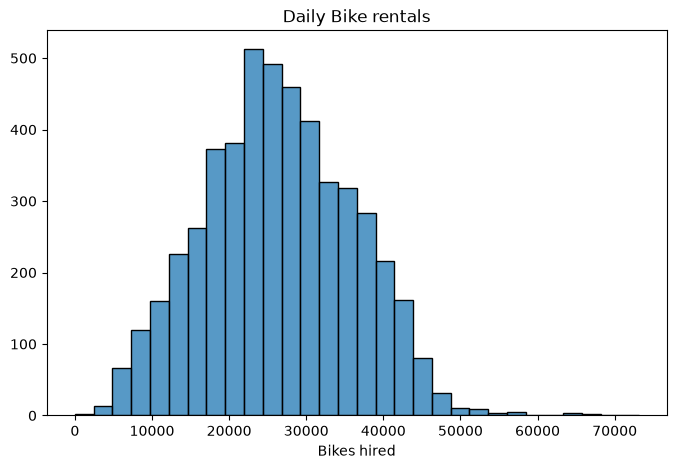

In [14]:
## Distribution of bikes rented
plt.figure(figsize=(8,5))

sns.histplot(data=bikes,
x="bikes_hired",
bins=30
             )
plt.title("Daily Bike rentals")
plt.xlabel("Bikes hired")
plt.ylabel("")

Text(0, 0.5, 'Bikes hired')

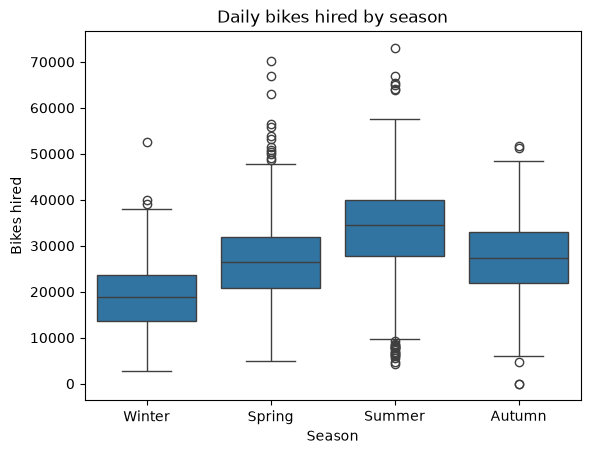

In [15]:
sns.boxplot(
    data=bikes,
    x="season",
    y = "bikes_hired",
)
plt.title("Daily bikes hired by season")
plt.xlabel("Season")
plt.ylabel("Bikes hired")

Text(0, 0.5, 'Bikes hired')

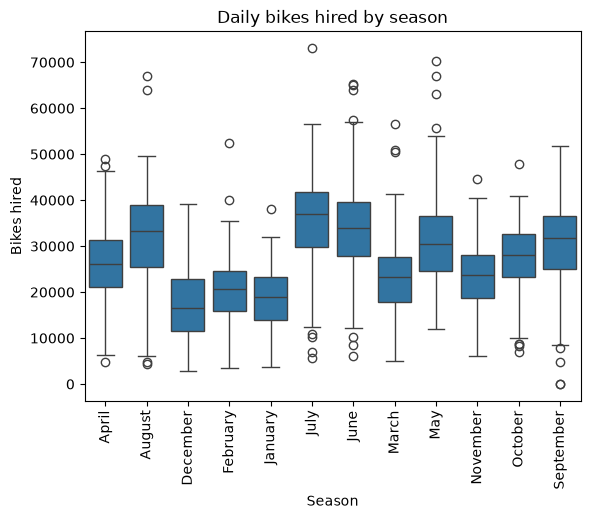

In [16]:
sns.boxplot(
    data=bikes,
    x="month_name",
    y = "bikes_hired",
)
plt.title("Daily bikes hired by season")
plt.xlabel("Season")
plt.xticks(rotation=90)
plt.ylabel("Bikes hired")

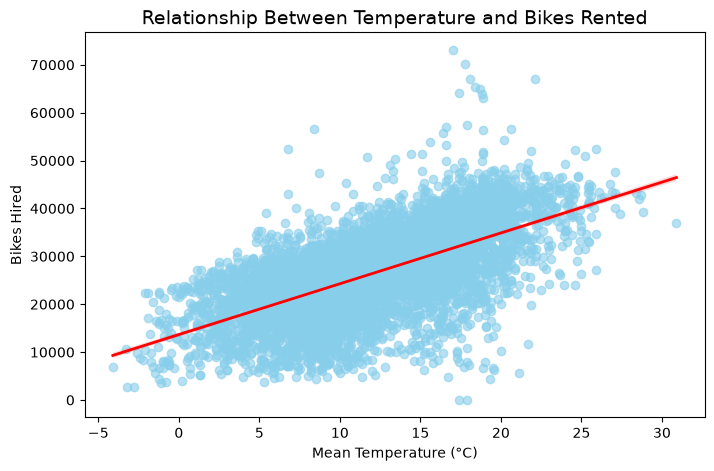

In [17]:
plt.figure(figsize=(8, 5))

# 使用 regplot 繪製散佈圖並自動加上線性迴歸趨勢線
sns.regplot(
    data=bikes,
    x="mean_temp",
    y="bikes_hired",
    color="skyblue",
    line_kws={"color": "red", "linewidth": 2},  # 調整趨勢線顏色與粗細
    scatter_kws={"alpha": 0.6},  # 調整散佈點透明度，避免點太密疊在一起
)

plt.title("Relationship Between Temperature and Bikes Rented", fontsize=14)
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Bikes Hired")

plt.show()

**3. Construct 95% confidence intervals for the mean number of bikes rented per season.**

Repeat the calculation per month.

Interpret the result:

What range of values do you expect the true mean to lie in?

Which seasons/months have higher or lower average demand?

Are there overlaps in the intervals, and what does that mean?

**Deliverables:**

A table or plot showing the mean and confidence intervals.

A short interpretation.

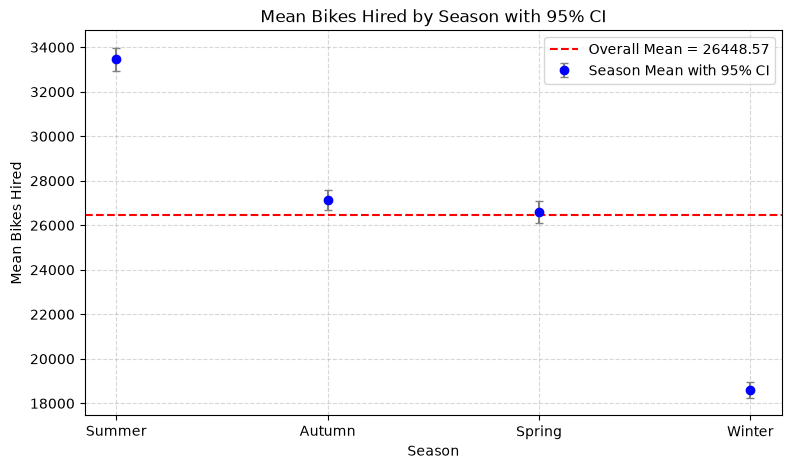

,season,Rental_mean,std,count,t_critical,ser,margin_of_error,CI_lower,CI_upper
2,Summer,33455.454841,9147.748858,1229,1.961898,260.938578,511.934790,32943.520052,33967.389631
3,Autumn,27136.845369,7857.506100,1274,1.961829,220.140533,431.878137,26704.967232,27568.723506
1,Spring,26609.178930,8660.272182,1196,1.961951,250.418236,491.308340,26117.870590,27100.487270
0,Winter,18610.162753,6625.762758,1235,1.961888,188.539522,369.893476,18240.269277,18980.056229


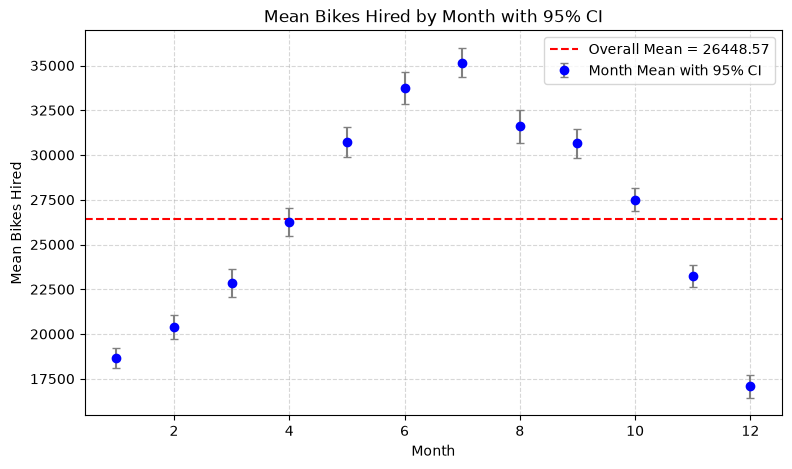

,month,Rental_mean,std,count,t_critical,ser,margin_of_error,CI_lower,CI_upper
6,7,35160.679012,8371.380378,405,1.965853,415.977235,817.750210,34342.928802,35978.429223
5,6,33744.102564,8765.336470,390,1.966081,443.850065,872.645209,32871.457355,34616.747773
7,8,31604.790323,9832.833248,434,1.965458,471.991100,927.678568,30677.111754,32532.468891
4,5,30722.198511,8561.905067,403,1.965883,426.498870,838.446734,29883.751777,31560.645245
8,9,30647.840476,8260.433461,420,1.965642,403.067881,792.287092,29855.553385,31440.127568
9,10,27510.831797,6896.999490,434,1.965458,331.066570,650.697358,26860.134440,28161.529155
3,4,26242.038462,7775.298629,390,1.966081,393.717551,774.080621,25467.957841,27016.119082
10,11,23239.397619,6516.006115,420,1.965642,317.948542,624.972958,22614.424661,23864.370577
2,3,22851.456576,7739.305269,403,1.965883,385.522256,757.891518,22093.565058,23609.348094
1,2,20370.174387,6528.789817,367,1.966467,340.800054,670.171966,19700.002421,21040.346353


In [18]:
## Your code goes here

def plot_group_ci(group_col, data=bikes, value_col='bikes_hired'):
    """
    根據指定的類別欄位計算平均值、95% CI，並繪製帶有誤差棒的點圖。
    
    參數:
    - group_col (str): 分組欄位名稱，例如 "season" 或 "month"
    - data (DataFrame): 輸入的原始 DataFrame，預設為 bikes
    - value_col (str): 要計算平均值的目標數值欄位，預設為 "bikes_hired"
    """
    # 1. 資料聚合與統計量計算
    df_ci = (
        data
        .groupby(group_col)[value_col]
        .agg(
            Rental_mean="mean",
            std="std",
            count="count"
        )
        .reset_index()
    )
    
    # 2. 計算 95% 信心區間 (t-distribution)
    df_ci['t_critical'] = df_ci['count'].apply(lambda n: stats.t.ppf(0.975, df=n-1))
    df_ci['ser'] = df_ci['std'] / np.sqrt(df_ci['count'])
    df_ci['margin_of_error'] = df_ci['t_critical'] * df_ci['ser']
    df_ci['CI_lower'] = df_ci['Rental_mean'] - df_ci['margin_of_error']
    df_ci['CI_upper'] = df_ci['Rental_mean'] + df_ci['margin_of_error']
    
    # 按平均值降冪排序
    df_ci = df_ci.sort_values(by='Rental_mean', ascending=False)
    
    # 3. 計算全體總平均值
    overall = data[value_col].mean()
    
    # 4. 繪製圖表
    plt.figure(figsize=(9, 5))
    
    # 繪製點圖與 95% CI 誤差棒
    plt.errorbar(
        x=df_ci[group_col], 
        y=df_ci['Rental_mean'], 
        yerr=df_ci['margin_of_error'],
        fmt='o', 
        ecolor='gray', 
        capsize=3,
        color='blue',
        label=f'{group_col.capitalize()} Mean with 95% CI'
    )
    
    # 繪製整體平均線
    plt.axhline(
        overall, 
        color='red', 
        linestyle='--',
        label=f'Overall Mean = {overall:.2f}'
    )
    
    # 圖表標籤與設定
    plt.xlabel(group_col.capitalize())
    plt.ylabel(f'Mean {value_col.replace("_", " ").title()}')
    plt.title(f'Mean {value_col.replace("_", " ").title()} by {group_col.capitalize()} with 95% CI')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()
    display(df_ci)
    



plot_group_ci("season")
plot_group_ci("month")





1. **Seasonal and Monthly Trends in Bike Hires (`bike_hired`):**
   - **Seasonal Pattern (Table 1):** The true population mean of bike hires for each season is estimated to fall within its respective confidence interval. **Summer** clearly exhibits the highest mean rental volume, whereas **winter** records the lowest.
   - **Monthly Pattern (Table 2):** The confidence intervals show that **months 5 through 8** (May to August) achieve the highest average bike hires.

2. **Statistical Significance of Overlapping Intervals:**
   - The overlap in confidence intervals among these months indicates that there is **no statistically significant difference** between their mean bike hire volumes.

**Regression Analysis**

What variables influence the number of bikes rented (y) and how? Build a regression model that best explains the variability in bikes rented.

**Interpret:**

Which predictors are significant?

What do the coefficients mean (in practical terms)?

How much of the variation in bike rentals is explained (R²)?

**Deliverables:**

Regression output table.

A short discussion of which factors matter most for predicting bike rentals.

### Your code goes here

**First we remove some feature that is not helpful**:
1. Remove repetitive information
    1. wday = day_of_week -> eliminate day_of_week
    2. month = month_name -> eliminate month_name
2. we need to avoid multicollinearity problem, we start with intuitive multicollinearity problem:**
    1. mean_temp = (min+max)/2 -> eliminate mean
    4. weekend_True = wday_Sat + wday_Sun -> eliminate weekend_True
    5. season_Spring = month_3 + month_4 + month_5
    season_Summer = month_6 + month_7 + month_8
    season_Autumn = month_9 + month_10 + month_11 -> eliminate season**
2. Standardize the numerica value
3. change categorical data into dummies
4. Do VCF Test to see whether their exsit strong collinearlty problem

In [21]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler


bikes.head(5)
#把重複的欄位拿掉 wday = day_of_week,month=month_name,，以及拿掉應變像
X = bikes.drop(columns=["date","day_of_week","month_name","bikes_hired"]) 

#把可能共線性的欄位拿掉
X = X.drop(columns=["mean_temp","weekend","season"])


# 1. 類別欄位
cat_cols = ['wday', 'month',"weekend","season","week"]
cat_cols = [col for col in cat_cols if col in X.columns]
num_cols = ["year", "min_temp","max_temp","mean_temp","humidity", "wind_speed","sunshine","cloud_cover","rainfall","pressure","precipitation","snow_depth","radiation","day"]
# 確保只篩選存在於 X 中的欄位
num_cols = [col for col in num_cols if col in X.columns]

print("selected variables:", X.columns.tolist())

X_V_test = X.copy()

# 初始化標準化器 (Mean=0, Std=1)
scaler = StandardScaler()

# 僅對連續變數欄位做 transform，Dummy 變數維持 0.0 / 1.0 不變
X_V_test[num_cols] = scaler.fit_transform(X_V_test[num_cols])

# 2. 類別資料轉 Dummy
X_V_test = pd.get_dummies(X_V_test, columns=cat_cols, drop_first=True, dtype=float)

# 3. 缺值、常數項
X_V_test = X_V_test.dropna()
X_V_test = sm.add_constant(X_V_test)




# # 計算 VIF 前再確認全部都是數值
assert X_V_test.dtypes.map(lambda t: t.kind in "fi").all(), X_V_test.dtypes[X_V_test.dtypes.map(lambda t: t.kind not in "fi")]

vif = pd.DataFrame({
    "feature": X_V_test.columns,
    "VIF": [variance_inflation_factor(X_V_test.values, i) for i in range(X_V_test.shape[1])],
})
print(vif[vif["feature"] != "const"].sort_values("VIF", ascending=False))

selected variables: ['year', 'wday', 'month', 'week', 'cloud_cover', 'humidity', 'pressure', 'radiation', 'precipitation', 'snow_depth', 'sunshine', 'min_temp', 'max_temp', 'day']
          feature        VIF
24        month_8  54.195152
23        month_7  52.802344
22        month_6  49.873700
25        month_9  48.493012
21        month_5  47.421446
..            ...        ...
80        week_53   1.316139
4        pressure   1.305415
6   precipitation   1.242834
7      snow_depth   1.064782
1            year   1.053711

[80 rows x 2 columns]


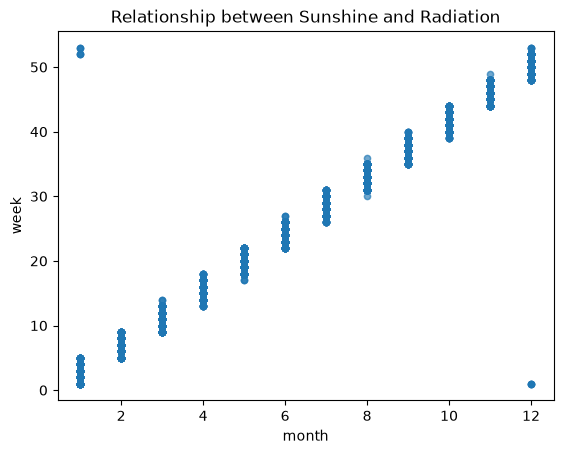

          month      week
month  1.000000  0.972215
week   0.972215  1.000000


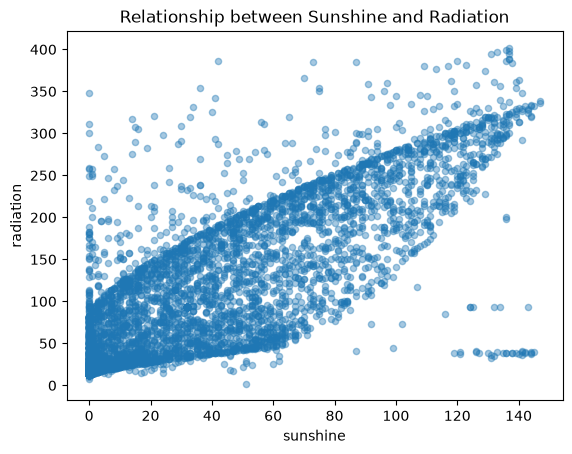

           sunshine  radiation
sunshine   1.000000   0.777869
radiation  0.777869   1.000000


In [23]:
#From the above we can see the VIF for month is extremely high also for the sunshine, meaning that it has high collinarity with others. So we do a further test of them

bikes.plot.scatter(x="month", y="week", alpha=0.4)
plt.title("Relationship between Sunshine and Radiation")
plt.show()
print(bikes[["month", "week"]].corr())

bikes.plot.scatter(x="sunshine", y="radiation", alpha=0.4)
plt.title("Relationship between Sunshine and Radiation")
plt.show()
print(bikes[["sunshine", "radiation"]].corr())

**Frome the above observation we could remove radiation and week, cause they have high correlation**

In [25]:

print(X.columns.tolist())
print(X.head(5))

test=X.copy()
# test = test.drop(columns=[ "radiation","week"])
test = test.drop(columns=[ "radiation","week",'min_temp','max_temp'])
test["mean_temp"]=bikes["mean_temp"]

print(test.columns.tolist())
print(test.head(5))


['year', 'wday', 'month', 'week', 'cloud_cover', 'humidity', 'pressure', 'radiation', 'precipitation', 'snow_depth', 'sunshine', 'min_temp', 'max_temp', 'day']
   year wday  month  week  cloud_cover  humidity  pressure  radiation  \
0  2010  Fri      7    30          6.0      65.0   10147.0      157.0   
1  2010  Sat      7    30          5.0      70.0   10116.0      184.0   
2  2010  Sun      8    30          7.0      63.0   10132.0       89.0   
3  2010  Mon      8    31          7.0      59.0   10168.0      134.0   
4  2010  Tue      8    31          5.0      66.0   10157.0      169.0   

   precipitation  snow_depth  sunshine  min_temp  max_temp  day  
0           22.0         0.0      31.0      12.3      25.1   30  
1            0.0         0.0      47.0      17.0      23.9   31  
2            0.0         0.0       3.0      14.6      23.4    1  
3            0.0         0.0      20.0      15.6      23.6    2  
4            0.0         0.0      39.0      12.1      20.1    3  
['yea

In [26]:
y = bikes['bikes_hired']


# 1. 類別欄位
cat_cols = ['wday', 'month',"weekend","season","week"]
cat_cols = [col for col in cat_cols if col in test.columns]
num_cols = ["year", "min_temp","max_temp","mean_temp","humidity", "wind_speed","sunshine","cloud_cover","rainfall","pressure","precipitation","snow_depth","radiation","day"]
# 確保只篩選存在於 X 中的欄位
num_cols = [col for col in num_cols if col in test.columns]

print("selected variables:", test.columns.tolist())



# 初始化標準化器 (Mean=0, Std=1)
scaler = StandardScaler()

# 僅對連續變數欄位做 transform，Dummy 變數維持 0.0 / 1.0 不變
test[num_cols] = scaler.fit_transform(test[num_cols])

# 2. 類別資料轉 Dummy
test = pd.get_dummies(test, columns=cat_cols, drop_first=True, dtype=float)

# 3. 缺值、常數項
test = test.dropna()
test = sm.add_constant(test)

# # 4. 處理 inf，並刪除有缺失值的列
test = test.replace([np.inf, -np.inf], np.nan)
mask = test.notna().all(axis=1) & y.notna()
print(f"刪除列數：{(~mask).sum()} / 總列數：{len(mask)}")
test = test[mask]
y = y[mask]

test = sm.add_constant(test)
print("欄位數:", test.shape[1], "/ rank:", np.linalg.matrix_rank(test))
model = sm.OLS(y, test).fit()

# 7. 輸出報告
print(model.summary())

selected variables: ['year', 'wday', 'month', 'cloud_cover', 'humidity', 'pressure', 'precipitation', 'snow_depth', 'sunshine', 'day', 'mean_temp']
刪除列數：0 / 總列數：4934
欄位數: 27 / rank: 27
                            OLS Regression Results                            
Dep. Variable:            bikes_hired   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     336.1
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:50:33   Log-Likelihood:                -49760.
No. Observations:                4934   AIC:                         9.957e+04
Df Residuals:                    4907   BIC:                         9.975e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                    coef 

## Deliverables
A knitted HTML, one person per group to submit